<a href="https://colab.research.google.com/github/pratheekselvan-jpg/Quantum-Computing-Journey/blob/main/QASE_Phase1_BellState.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# The '%' tells Colab to install this into the background environment Note: pylatexenc is what allows you to draw those pretty circuit diagrams.
%pip install qiskit qiskit-ibm-runtime pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 9.8 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=329c321d5d9a1a9543d175c2327562ca39f80233f7ecb729bf0bc153654bdb63
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [9]:
from google.colab import userdata
from qiskit_ibm_runtime import QiskitRuntimeService

MY_TOKEN = userdata.get('IBM_TOKEN')
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=MY_TOKEN)

qiskit_runtime_service._discover_account:WARNING:2026-03-05 15:40:53,200: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-03-05 15:40:56,763: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


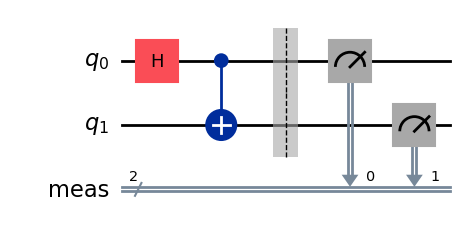

In [10]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

# 1. Build the Circuit
qc = QuantumCircuit(2) # 2 qubits
qc.h(0)                # Superposition on Q0
qc.cx(0, 1)            # Entangle Q0 and Q1
qc.measure_all()       # Measure the results

# 2. Draw it to make sure it's correct
qc.draw(output='mpl')

Final Counts: {'00': 510, '11': 514}


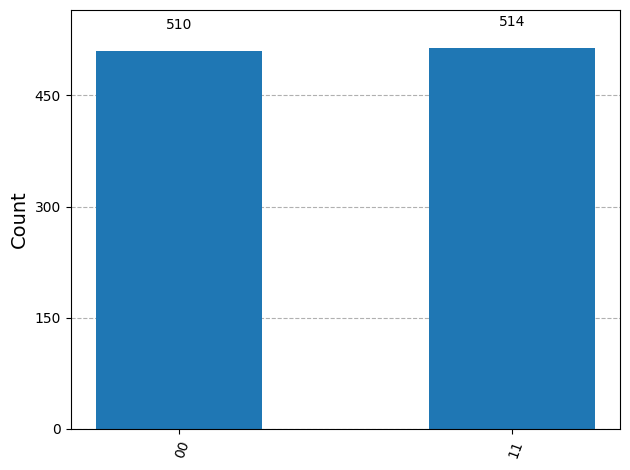

In [11]:
from qiskit.primitives import StatevectorSampler

# Run the simulation
sampler = StatevectorSampler()
job = sampler.run([qc], shots=1024)
result = job.result()

# Get and plot results
counts = result[0].data.meas.get_counts()
print(f"Final Counts: {counts}")
plot_histogram(counts)